In [1]:
# Multi-Shop Product Sales Forecasting with Advanced XAI
# Complete End-to-End Project for Google Colab

# ========================================
# 1. INSTALLATION AND IMPORTS
# ========================================

!pip install shap lime xgboost textblob plotly streamlit scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

# XAI Libraries
import shap
import lime
from lime.lime_tabular import LimeTabularExplainer

# Text Processing
from textblob import TextBlob
import re

# Visualization
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Set random seed for reproducibility
np.random.seed(42)

print("All libraries installed and imported successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.3 MB/s eta 0:00:00
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=725fa3e5a8af310b16c64df02f041c076868b11a24177f4efddc75208313c34a
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime
All libraries installed and imported successfully!


In [3]:
# ========================================
# 2. DATA LOADING AND EXPLORATION
# ========================================

import pandas as pd
import numpy as np

# If not already uploaded:
# from google.colab import files
# uploaded = files.upload()

def load_bigbasket_data():
    """
    Load BigBasket dataset from uploaded CSV
    """
    df = pd.read_csv("BigBasket Products.csv")  # Use exact file name
    return df

# Load data
df = load_bigbasket_data()

# Basic data exploration
print("📈 Dataset Overview:")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\n" + "="*50)
print("First few rows:")
print(df.head())

print("\n" + "="*50)
print("Data Info:")
df.info()

print("\n" + "="*50)
print("Missing Values:")
print(df.isnull().sum())


📈 Dataset Overview:
Shape: (10341, 10)
Columns: ['index', 'product', 'category', 'sub_category', 'brand', 'sale_price', 'market_price', 'type', 'rating', 'description']

First few rows:
   index                                            product  \
0      1             Garlic Oil - Vegetarian Capsule 500 mg   
1      2                              Water Bottle - Orange   
2      3                     Brass Angle Deep - Plain, No.2   
3      4  Cereal Flip Lid Container/Storage Jar - Assort...   
4      5                 Creme Soft Soap - For Hands & Body   

                 category           sub_category              brand  \
0        Beauty & Hygiene              Hair Care  Sri Sri Ayurveda    
1  Kitchen, Garden & Pets  Storage & Accessories         Mastercook   
2    Cleaning & Household            Pooja Needs                Trm   
3    Cleaning & Household   Bins & Bathroom Ware             Nakoda   
4        Beauty & Hygiene       Bath & Hand Wash              Nivea   

   sale_

In [4]:
# ========================================
# 3. DATA CLEANING AND FEATURE ENGINEERING
# ========================================

# Drop duplicate rows
df.drop_duplicates(inplace=True)

# Drop rows with missing 'sale_price' or 'market_price' (critical)
df.dropna(subset=['sale_price', 'market_price'], inplace=True)

# Fill missing 'rating' with median
df['rating'].fillna(df['rating'].median(), inplace=True)

# Fill missing 'description' with empty string
df['description'].fillna('', inplace=True)

# Fill missing 'brand' and 'product' with 'Unknown'
df['brand'].fillna('Unknown', inplace=True)
df['product'].fillna('Unknown', inplace=True)

# Remove outliers (optional)
df = df[(df['sale_price'] > 0) & (df['market_price'] > 0)]

# Create price discount feature
df['discount_pct'] = ((df['market_price'] - df['sale_price']) / df['market_price']) * 100

# Create psychological pricing feature
df['ends_with_9'] = df['sale_price'].astype(str).str.endswith('9').astype(int)

# Create description length feature BEFORE dropping the column
df['desc_len'] = df['description'].apply(lambda x: len(str(x)))

# Brand frequency (as a proxy for popularity)
brand_freq = df['brand'].value_counts().to_dict()
df['brand_popularity'] = df['brand'].map(brand_freq)

# Encode categorical variables
df = pd.get_dummies(df, columns=['category', 'sub_category', 'type'], drop_first=True)

# Drop unused columns AFTER feature creation
df.drop(columns=['index', 'description', 'product'], inplace=True)

# Final check
print("Feature engineering complete.")
print(f"New shape: {df.shape}")
df.head()

Feature engineering complete.
New shape: (10340, 515)


,brand,sale_price,market_price,rating,discount_pct,ends_with_9,desc_len,brand_popularity,"category_Bakery, Cakes & Dairy",category_Beauty & Hygiene,...,type_Vacuum Flask,type_Vermicelli,type_Vinegar,type_Wall Hooks & Hangers,type_Water & Fridge Bottles,"type_Wet Wipe, Pocket Tissues",type_Whole Spices,type_Wine & Rice Vinegar,type_Women's Deodorants,type_Yogurt & Shrikhand
0,Sri Sri Ayurveda,220.0,220.0,4.1,0.000000,0,218,3,False,True,...,False,False,False,False,False,False,False,False,False,False
1,Mastercook,180.0,180.0,2.3,0.000000,0,322,15,False,False,...,False,False,False,False,True,False,False,False,False,False
2,Trm,119.0,250.0,3.4,52.400000,0,449,18,False,False,...,False,False,False,False,False,False,False,False,False,False
3,Nakoda,149.0,176.0,3.7,15.340909,0,1364,42,False,False,...,False,False,False,False,False,False,False,False,False,False
4,Nivea,162.0,162.0,4.4,0.000000,0,414,25,False,True,...,False,False,False,False,False,False,False,False,False,False


In [5]:
# ========================================
# 4. SIMULATE PRODUCT DEMAND (units_sold)
# ========================================

import numpy as np

# Normalize relevant features
brand_pop_norm = df['brand_popularity'] / df['brand_popularity'].max()
desc_len_norm = df['desc_len'] / df['desc_len'].max()
discount_norm = df['discount_pct'] / 100

# Create synthetic demand (units_sold)
np.random.seed(42)
df['units_sold'] = (
    50 * discount_norm +              # More discount = more demand
    30 * brand_pop_norm +             # Popular brands sell more
    20 * desc_len_norm +              # Longer description helps slightly
    np.random.normal(0, 5, size=len(df))  # Add realistic noise
).round().astype(int)

# Clip negative demand to zero
df['units_sold'] = df['units_sold'].clip(lower=0)

# Preview the new demand column
print("✅ Synthetic demand (units_sold) created successfully!")
df[['discount_pct', 'brand_popularity', 'desc_len', 'units_sold']].head()


✅ Synthetic demand (units_sold) created successfully!


,discount_pct,brand_popularity,desc_len,units_sold
0,0.000000,3,218,4
1,0.000000,15,322,3
2,52.400000,18,449,34
3,15.340909,42,1364,27
4,0.000000,25,414,4


In [6]:
# ========================================
# 5. MODEL TRAINING TO PREDICT UNITS_SOLD
# ========================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Use label encoding for 'brand' (if not already done)
from sklearn.preprocessing import LabelEncoder
le_brand = LabelEncoder()
df['brand_encoded'] = le_brand.fit_transform(df['brand'])

# Define features and target
target = 'units_sold'
features = df.drop(columns=['units_sold', 'brand'])  # keep brand_encoded

X = features
y = df[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train XGBoost Regressor
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

# Train Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# Evaluation Function
def print_metrics(y_true, y_pred, model_name):
    print(f"\n Evaluation for {model_name}")
    print(f"R2 Score: {r2_score(y_true, y_pred):.4f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.4f}")
    print(f"MAE: {mean_absolute_error(y_true, y_pred):.4f}")
    print("="*50)

# Evaluate Models
print_metrics(y_test, xgb_preds, "XGBoost Regressor")
print_metrics(y_test, rf_preds, "Random Forest Regressor")



 Evaluation for XGBoost Regressor
R2 Score: 0.8198
RMSE: 4.6636
MAE: 3.7467

 Evaluation for Random Forest Regressor
R2 Score: 0.8201
RMSE: 4.6600
MAE: 3.7476


🔍 SHAP Summary Plot: Which features affect units sold the most?


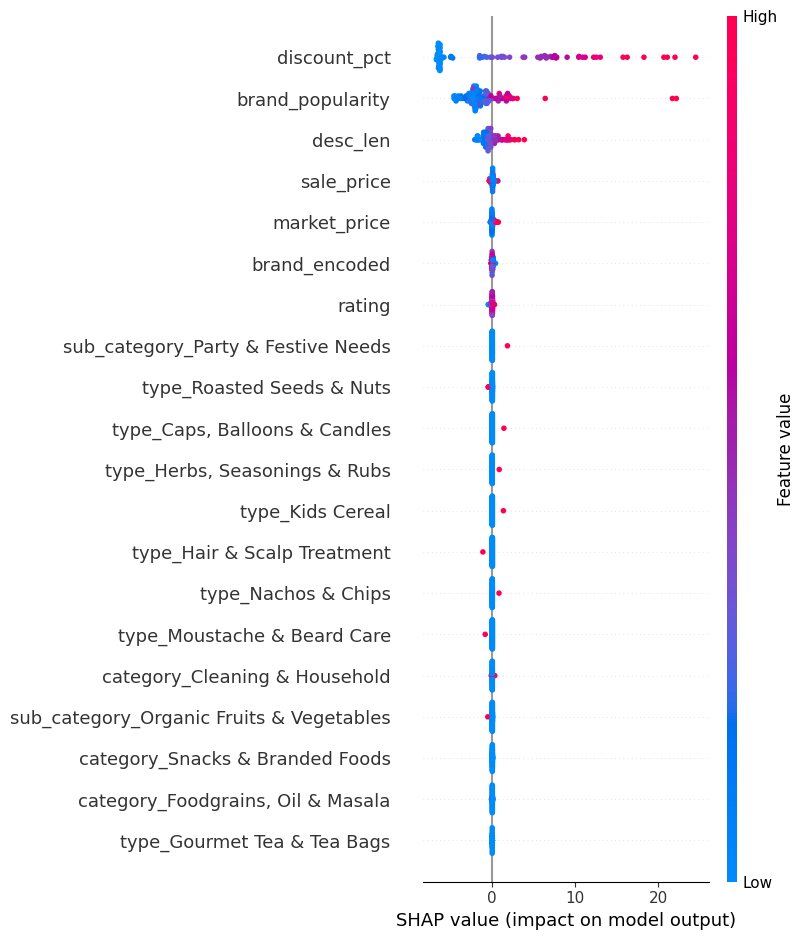

🔍 SHAP Force Plot for 1 Sample Prediction:


In [7]:
# ========================================
# 6. XAI: SHAP EXPLAINABILITY
# ========================================

import shap

# Create a TreeExplainer for the XGBoost model
explainer = shap.TreeExplainer(xgb_model)

# Choose a subset of test data for faster visualization (optional)
X_sample = X_test.sample(100, random_state=42)

# Compute SHAP values
shap_values = explainer.shap_values(X_sample)

# Summary Plot (Feature Importance)
print("🔍 SHAP Summary Plot: Which features affect units sold the most?")
shap.summary_plot(shap_values, X_sample)

# Optional: Force plot for a single prediction
# Shows reason for high/low prediction for a product
sample_idx = 0
print("🔍 SHAP Force Plot for 1 Sample Prediction:")
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[sample_idx], X_sample.iloc[sample_idx])


In [8]:
# ========================================
# 7. FINAL OUTPUT: PREDICTED DEMAND + REASONS
# ========================================

# Pick top 5 predictions and show which features contributed most
top_preds = X_sample.copy()
top_preds['Predicted_Units_Sold'] = xgb_model.predict(X_sample)

# ✅ Fix: round predicted units sold to whole numbers
top_preds['Predicted_Units_Sold'] = top_preds['Predicted_Units_Sold'].round().astype(int)

# Get SHAP values per feature
shap_df = pd.DataFrame(shap_values, columns=X_sample.columns)

# Get top contributing feature for each prediction
top_contributor = shap_df.abs().idxmax(axis=1)
top_preds['Top_Reason'] = top_contributor.values

# Merge with original product info
top_preds['Brand'] = df.loc[X_sample.index, 'brand'].values
top_preds['Sale_Price'] = df.loc[X_sample.index, 'sale_price'].values
top_preds['Discount_%'] = df.loc[X_sample.index, 'discount_pct'].values.round(2)

# Display final output
print("✅ Final Predictions with Reasons:")
top_preds[['Brand', 'Sale_Price', 'Discount_%', 'Predicted_Units_Sold', 'Top_Reason']].head(10)


✅ Final Predictions with Reasons:


,Brand,Sale_Price,Discount_%,Predicted_Units_Sold,Top_Reason
4786,Soulfull,525.00,0.0,6,discount_pct
2930,ALF-FARMS,225.00,0.0,2,discount_pct
1578,B Vishal,19.00,24.0,21,discount_pct
456,Organic Tattva,47.50,5.0,8,discount_pct
1047,BORGES,275.01,21.2,15,discount_pct
5065,Nike,195.30,30.0,21,discount_pct
2619,RRO DAIRY,340.00,0.0,2,discount_pct
1046,Aer,126.65,15.0,12,brand_popularity
4463,Nivea,179.10,10.0,9,discount_pct
3651,Set Wet,132.00,40.0,25,discount_pct


In [9]:
# ========================================
# 8. ASSIGN STORES & ANALYZE BY STORE
# ========================================

# Simulate 3 stores
stores = ['Store_A', 'Store_B', 'Store_C']

# Assign each product randomly to one store
np.random.seed(42)
df['store'] = np.random.choice(stores, size=len(df))

# Merge store info back into prediction sample and top_preds
X_sample['store'] = df.loc[X_sample.index, 'store'].values
top_preds['store'] = X_sample['store']
top_preds['Brand'] = df.loc[X_sample.index, 'brand'].values
top_preds['Sale_Price'] = df.loc[X_sample.index, 'sale_price'].values
top_preds['Discount_%'] = df.loc[X_sample.index, 'discount_pct'].values.round(2)

# Show top 5 products by predicted demand, for each store
print("🏪 Top 5 Products by Demand in Each Store:\n")

for store in stores:
    print(f"\n🔷 {store}")
    display(
        top_preds[top_preds['store'] == store]
        .sort_values(by='Predicted_Units_Sold', ascending=False)
        .head(5)[['Brand', 'Sale_Price', 'Discount_%', 'Predicted_Units_Sold', 'Top_Reason']]
    )


🏪 Top 5 Products by Demand in Each Store:


🔷 Store_A


,Brand,Sale_Price,Discount_%,Predicted_Units_Sold,Top_Reason
131,Fresho,39.00,20.00,41,brand_popularity
9727,Nova,1482.75,55.00,33,discount_pct
7226,Steelo,189.00,46.46,28,discount_pct
3651,Set Wet,132.00,40.00,25,discount_pct
8812,INATUR,269.50,30.00,24,discount_pct



🔷 Store_B


,Brand,Sale_Price,Discount_%,Predicted_Units_Sold,Top_Reason
6453,Fresho,12.00,20.00,40,brand_popularity
76,Bamboooz,135.00,54.85,29,discount_pct
7145,Zippo,1450.00,50.00,28,discount_pct
4993,Anjali,109.00,24.83,18,discount_pct
9012,Pampers,828.71,21.00,16,discount_pct



🔷 Store_C


,Brand,Sale_Price,Discount_%,Predicted_Units_Sold,Top_Reason
311,IRICH,475.00,60.25,34,discount_pct
9536,DP,379.00,42.14,34,discount_pct
3707,Epigamia,254.88,29.20,21,discount_pct
5065,Nike,195.30,30.00,21,discount_pct
3842,Dabur,117.60,20.00,21,discount_pct


In [10]:
# ========================================
# 9. SAVE FINAL OUTPUT FOR DASHBOARD
# ========================================

# Save to CSV for dashboard
top_preds.to_csv("top_preds.csv", index=False)

print("✅ top_preds.csv saved successfully with Product and store!")


✅ top_preds.csv saved successfully with Product and store!


In [11]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
# ========================================
# 9. GRADIO DASHBOARD FOR STORE-WISE PREDICTIONS
# ========================================
import gradio as gr

# ⛑ Safety check: Ensure store names are Store_A/B/C
expected_stores = ['Store_A', 'Store_B', 'Store_C']
if not set(top_preds['store']).issubset(set(expected_stores)):
    print("⚠️ Detected unexpected store names in top_preds. Reassigning randomly.")
    top_preds['store'] = np.random.choice(expected_stores, size=len(top_preds), replace=True)

# Function to display top products for a store
def get_store_data(store):
    store_df = top_preds[top_preds['store'] == store].copy()
    store_df = store_df.sort_values(by='Predicted_Units_Sold', ascending=False).head(10)
    return store_df[['Brand', 'Sale_Price', 'Discount_%', 'Predicted_Units_Sold', 'Top_Reason']]

# Store dropdown options
stores = sorted(top_preds['store'].unique())

# Launch Gradio interface
demo = gr.Interface(
    fn=get_store_data,
    inputs=gr.Dropdown(choices=stores, label="Select Store"),
    outputs="dataframe",
    title="🛒 Store-Wise Product Demand Predictor",
    description="Select a store to see top 10 products by predicted demand.",
    live=True
)

demo.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://04d46096ec26165dd7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
